In [43]:
import pandas as pd

In [44]:
titanic_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(titanic_url)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [45]:
titanic.shape

(891, 15)

In [46]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [47]:
# Find the total number of null values in age column
titanic['age'].isnull().sum()

np.int64(177)

In [48]:
# Replace null values in age column with the mean age
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

C:\Users\Tanzeem Rahat\AppData\Local\Temp\ipykernel_13268\875402784.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['age'].fillna(titanic['age'].mean(), inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

In [49]:
# Create a new column 'age_group' based on the 'age' column
titanic['age_group'] = pd.cut(titanic['age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Middle-aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adult


In [50]:
# Counting the number of adults
titanic['age_group'].value_counts()

age_group
Adult          358
Middle-aged    195
Teen            70
Child           69
Senior          22
Name: count, dtype: int64

In [51]:
# Filter the DataFrame to include only adults
adults = titanic[titanic['age_group'] == 'Adult']
adults.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Adult
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,Adult


In [52]:
adults.shape

(358, 16)

In [53]:
# Sorting the DataFrame by 'fare' in descending order
adults_sorted = adults.sort_values(by='fare', ascending=False)
adults_sorted.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group
737,1,1,male,35.0,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True,Adult
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True,Adult
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False,Adult
341,1,1,female,24.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False,Adult
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,Adult


In [54]:
# Example of groupby operation: average fare by age group
average_by_age_group = titanic.groupby('age_group')['fare'].mean()
print(average_by_age_group)

age_group
Child          31.536352
Teen           33.451313
Adult          29.925929
Middle-aged    44.259658
Senior         41.371214
Name: fare, dtype: float64


In [55]:
# Summarize using pivot table: average fare by age group and class
pivot_table = titanic.pivot_table(
    values = 'fare',
    index = 'age_group',
    columns = 'class',
    aggfunc = 'mean'
)
print(pivot_table)

class             First     Second      Third
age_group                                    
Child        126.239575  28.740200  24.634721
Teen         122.537500  21.172567  13.414589
Adult        100.263321  21.400798  10.527417
Middle-aged   76.983334  19.760638  13.334195
Senior        59.969050  10.500000   7.820000


<Axes: title={'center': 'Average Fare by Age Group'}, xlabel='age_group'>

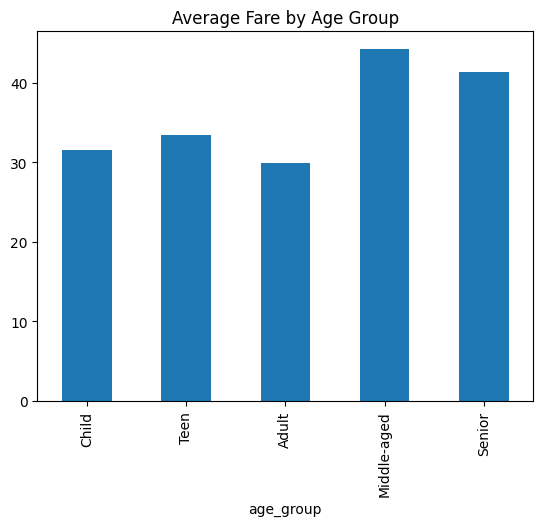

In [57]:
# Simple plotting: average fare by age group
average_by_age_group.plot(kind='bar', title='Average Fare by Age Group')